# Credit Risk Project
## Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the cleaned credit card default dataset.  
The objective is to understand customer behavior, identify patterns associated with default risk, and generate insights that will guide feature engineering and model selection in subsequent stages.

This analysis is descriptive and diagnostic in nature. No transformations that alter the underlying data distribution are applied in this notebook.

### Objectives of Exploratory Data Analysis

The key goals of this EDA are to:

- Examine the distribution of the target variable (default vs non-default)
- Compare behavioral and demographic characteristics of defaulters and non-defaulters
- Analyze repayment behavior and delinquency patterns
- Understand credit exposure through billing and payment trends
- Identify potential predictors of default risk
- Highlight modeling considerations such as skewness, outliers, and multicollinearity

### Import Libraries & Load Clean Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_excel("default of credit card clients.xls", header=1)
df.drop(columns=['ID'], inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Dataset Overview

Before deep analysis, we reconfirm the dataset structure, data types, and presence of missing values to ensure analytical integrity.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

### TARGET DISTRIBUTION

### Target Variable: Default Status

The target variable `default payment next month` indicates whether a customer defaulted on their next payment.

- `0` → No default  
- `1` → Default  

Understanding class distribution is critical because credit default datasets are typically imbalanced, which directly affects model evaluation and risk calibration.


In [ ]:
df['default payment next month'].value_counts()
df['default payment next month'].value_counts(normalize=True)

,proportion
default payment next month,
0,0.7788
1,0.2212


### Target Variable Distribution Insight

The default variable is moderately imbalanced:

- **77.88%** of customers did **not default**
- **22.12%** of customers **defaulted**

This distribution reflects a realistic consumer credit portfolio where defaults are relatively infrequent but financially material.

**Business Implications:**
- Accuracy alone will be misleading for model evaluation
- Recall and precision for the default class will be critical
- Cost-sensitive modeling approaches may be required
- The model must focus on identifying high-risk customers rather than maximizing overall accuracy


### UNIVARIATE ANALYSIS (CREDIT LIMIT)

### Credit Limit Distribution (`LIMIT_BAL`)

Credit limit represents customer exposure and is a critical driver of both default probability and loss severity.

We examine:
- Distribution shape
- Skewness
- Presence of high-limit outliers


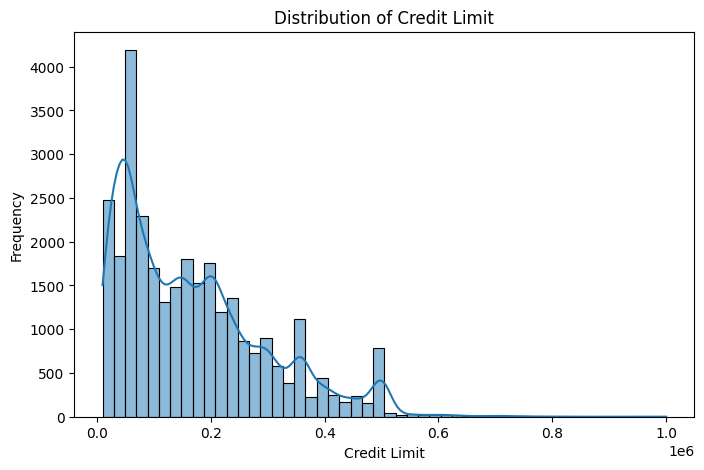

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['LIMIT_BAL'], bins=50, kde=True)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

### Credit Limit Distribution (LIMIT_BAL)

The distribution of approved credit limits is highly right-skewed, with a long tail extending toward very high limits.

Key observations:

- The majority of customers hold relatively low to mid-range credit limits, concentrated well below the maximum observed values.
- A small subset of customers have exceptionally high credit limits, creating a long right tail in the distribution.
- The presence of extreme high-limit outliers indicates **exposure concentration risk**, where a small number of accounts contribute disproportionately to potential loss.

Risk interpretation:

- Credit limit is a primary driver of **loss severity**, even if default probability remains low.
- Defaults among high-limit customers can materially impact portfolio losses.
- This distribution justifies treating credit limit as a critical feature and supports segmentation or interaction effects with delinquency behavior in modeling.


### BOX PLOT

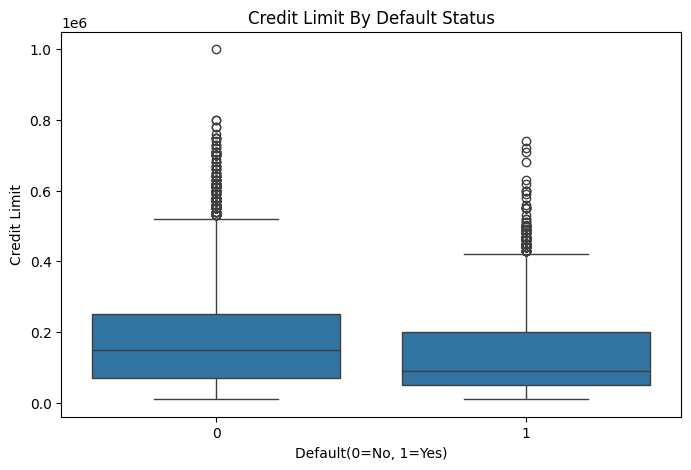

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.title("Credit Limit By Default Status")
plt.xlabel("Default(0=No, 1=Yes)")
plt.ylabel("Credit Limit")
plt.show()

### Credit Limit vs Default Behavior

The boxplot shows a clear separation in credit limit distributions between defaulters and non-defaulters.

Key observations:
- Customers who **default** tend to have **lower median credit limits**
- Non-defaulters show a wider spread with higher upper-end limits
- Extreme high credit limits exist in both groups, but are more common among non-defaulters

**Risk Interpretation:**
- Lower credit limits may reflect risk-based limit assignment
- Higher credit limits amplify potential loss severity even when default probability is lower
- Credit limit is a critical exposure variable and must be modeled jointly with delinquency behavior


### AGE HISTOGRAM

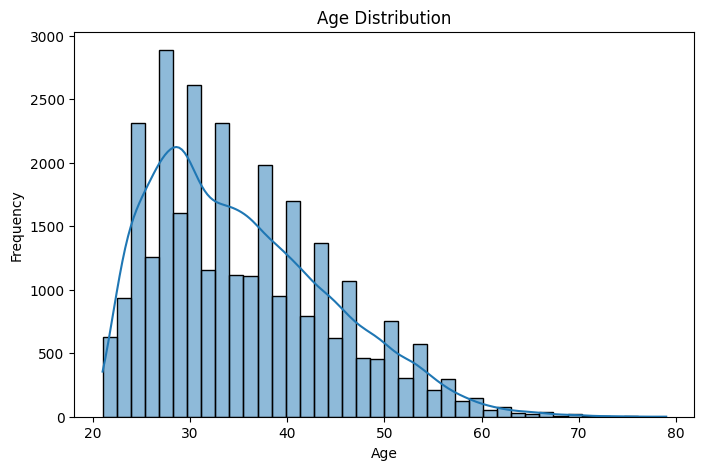

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['AGE'], bins=40, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Age Distribution Analysis

The age distribution is right-skewed, with the majority of customers concentrated between **25 and 45 years**.

Observations:
- Younger customers dominate the portfolio
- Default risk may vary across life stages due to income stability and financial maturity
- Very elderly customers are relatively rare

**Risk Perspective:**
- Age is expected to act as a supporting risk factor
- Non-linear effects may exist and should be evaluated during modeling


### Age vs Default Risk

This comparison evaluates whether default risk varies meaningfully across age groups.


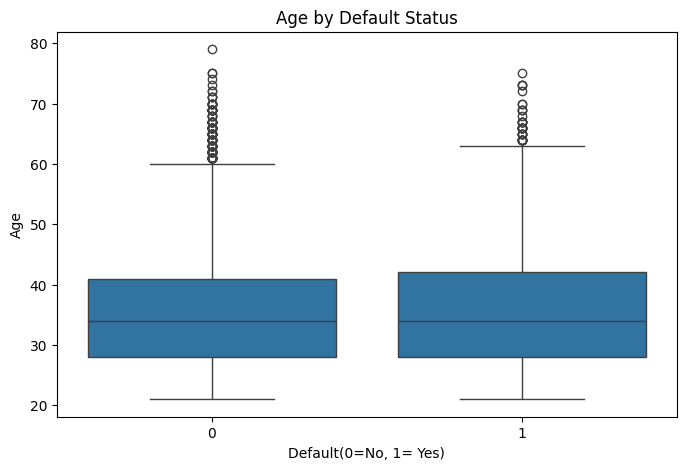

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='default payment next month', y='AGE', data=df)
plt.title("Age by Default Status")
plt.xlabel("Default(0=No, 1= Yes)")
plt.ylabel("Age")
plt.show()

### Age by Default Status

The boxplot compares the age distribution of defaulters and non-defaulters.

Key observations:

- The median ages of defaulters and non-defaulters are relatively similar, indicating that age alone is not a strong discriminator of default risk.
- Defaulters exhibit slightly higher dispersion, with more extreme values at older ages.
- Both groups show substantial overlap across the entire age range.

Risk interpretation:

- Age is a **weak standalone predictor** of default risk.
- Default behavior is not concentrated in a specific age segment but is spread across the population.
- Age may contribute marginal predictive value when combined with behavioral variables but should not be relied upon independently.


### Repayment Status Variables (`PAY_0` to `PAY_6`)

Repayment status variables capture delinquency severity over the last six months.
They are among the strongest predictors of credit default.

Values represent:
- `-2`: No consumption
- `-1`: Paid in full
- `0`: Revolving credit
- `1–8`: Increasing months of delinquency


In [ ]:
df.groupby('PAY_0')['default payment next month'].mean()

,default payment next month
PAY_0,
-2,0.132294
-1,0.167781
0,0.128113
1,0.339479
2,0.691414
3,0.757764
4,0.684211
5,0.500000
6,0.545455


### Repayment Status and Default Risk

Default rates increase sharply with worsening repayment status.

Key findings:
- Customers with **on-time payments or no usage** (PAY_0 ≤ 0) show low default rates
- Default probability rises significantly once payments are delayed by **1 month or more**
- Severe delinquency levels (PAY_0 ≥ 2) exhibit extremely high default rates

**Risk Interpretation:**
- Repayment status is the strongest behavioral predictor of default
- Even a single month of delinquency materially increases risk
- Persistent delinquency indicates structural inability or unwillingness to repay

These variables should be treated as primary drivers in credit risk modeling.


### Billing Amounts (`BILL_AMT1` – `BILL_AMT6`)

Billing amounts reflect utilization and outstanding balances.
We examine their distributions to understand exposure volatility and tail risk.


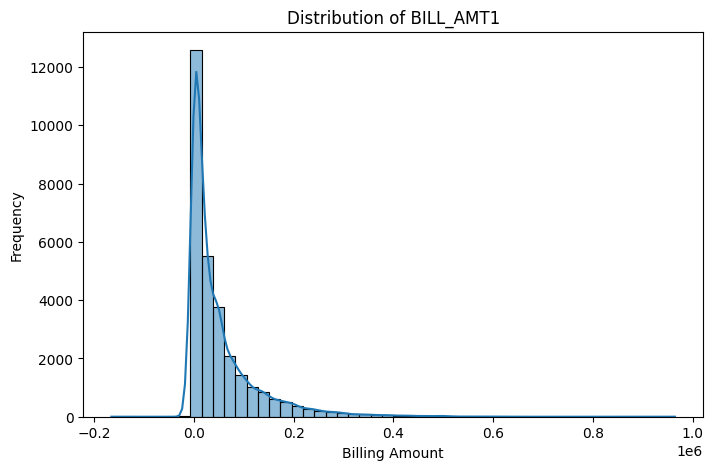

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['BILL_AMT1'], bins=50, kde=True)
plt.title("Distribution of BILL_AMT1")
plt.xlabel("Billing Amount")
plt.ylabel("Frequency")
plt.show()

### Distribution of BILL_AMT1

Billing amounts show a highly right-skewed distribution with a heavy tail.

Key observations:
- Most customers carry relatively low to moderate outstanding balances.
- Extreme positive values indicate very high utilization for a small subset of customers.
- Negative billing amounts are present, which likely reflect credits, refunds, or account adjustments rather than data errors.

Risk interpretation:
- Billing amounts capture utilization intensity and exposure volatility.
- Customers with persistently high billing amounts represent elevated exposure risk.
- Extreme balances contribute to tail risk and should be carefully handled during modeling (e.g., via transformations or robust models).

### Payment Amounts (`PAY_AMT1` – `PAY_AMT6`)

Payment behavior provides insight into liquidity, discipline, and stress.
Zero or minimal payments may indicate financial distress.

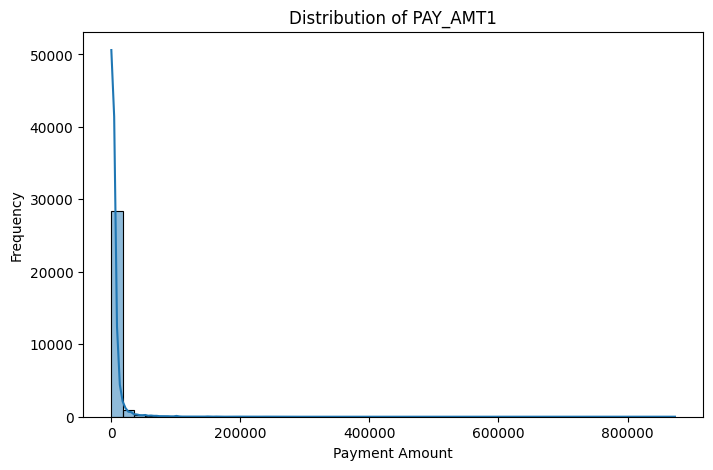

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['PAY_AMT1'], bins=50, kde=True)
plt.title("Distribution of PAY_AMT1")
plt.xlabel("Payment Amount")
plt.ylabel("Frequency")
plt.show()

### Distribution of PAY_AMT1

Payment amounts are extremely right-skewed, with a large mass at or near zero.

Key observations:
- A significant proportion of customers make very small or zero payments in a given month.
- A long right tail indicates that a small subset makes very large lump-sum payments.
- High dispersion suggests heterogeneous repayment capacity and behavior.

Risk interpretation:
- Zero or minimal payments may indicate liquidity stress or early signs of delinquency.
- Large payments may represent balance clearances, income inflows, or reactive behavior after missed payments.
- Payment behavior provides critical insight into short-term financial discipline and should be modeled alongside delinquency indicators.


### Demographic Factors and Default

We examine default rates across:
- Gender (`SEX`)
- Education level (`EDUCATION`)
- Marital status (`MARRIAGE`)

The objective is to detect segmentation patterns, not to make causal or normative claims.


In [ ]:
df.groupby('EDUCATION')['default payment next month'].mean()

,default payment next month
EDUCATION,
0,0.000000
1,0.192348
2,0.237349
3,0.251576
4,0.056911
5,0.064286
6,0.156863


In [ ]:
df.groupby('SEX')['default payment next month'].mean()

,default payment next month
SEX,
1,0.241672
2,0.207763


In [ ]:
df.groupby('MARRIAGE')['default payment next month'].mean()

,default payment next month
MARRIAGE,
0,0.092593
1,0.234717
2,0.209283
3,0.260062


### Demographic Default Rate Analysis

#### Education
- Default rates increase from graduate to high school categories
- Lower education levels show higher financial vulnerability
- "Other/Unknown" categories show lower default rates, likely due to data consolidation

#### Gender
- Male customers exhibit a slightly higher default rate than female customers
- Gender differences exist but are modest compared to behavioral variables

#### Marital Status
- Single and "Other" categories show higher default rates
- Married customers demonstrate relatively lower default risk

**Business Insight:**
Demographic variables provide useful segmentation context but should not be treated as primary risk drivers. Behavioral and repayment variables dominate predictive power.


### Correlation Analysis
We analyze correlations among numeric variables to:
- Identify multicollinearity risks
- Guide feature selection and regularization strategies


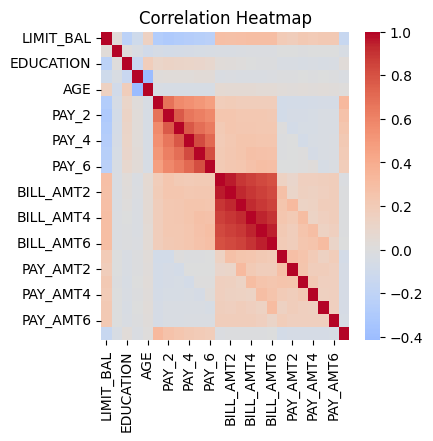

In [ ]:
plt.figure(figsize=(4,4))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap — Behavioral and Exposure Variables

The correlation heatmap highlights the structural relationships between exposure, repayment behavior, and payment activity.

Key observations:

- **Strong positive correlations among repayment status variables (PAY_2 to PAY_6)**  
  This indicates persistence in delinquency behavior. Customers who fall behind in one month are likely to remain delinquent in subsequent months, confirming temporal dependency in credit behavior.

- **Strong correlations among billing amounts (BILL_AMT2 to BILL_AMT6)**  
  Billing balances are highly autocorrelated over time, reflecting stable credit usage patterns and gradual balance evolution rather than abrupt changes.

- **Moderate correlation between billing amounts and payment amounts**  
  Higher balances are generally associated with higher payments, but the relationship is far from perfect. This suggests varying repayment discipline across customers.

- **Weak correlation between demographic variables (AGE, EDUCATION) and behavioral features**  
  Behavioral variables dominate the risk signal, reinforcing that repayment and utilization patterns are more predictive than static demographics.

- **LIMIT_BAL shows moderate correlation with billing and payment variables**  
  Higher credit limits naturally allow higher balances and payments, but do not directly imply higher delinquency, indicating that exposure size and risk behavior must be evaluated jointly.

Risk interpretation:
- Credit risk is driven primarily by **behavioral persistence** rather than isolated events.
- High multicollinearity exists within time-series variables, justifying aggregation and feature engineering rather than raw monthly inputs.
- Models should prioritize behavioral features and carefully manage correlated predictors.


## Exploratory Data Analysis — Key Risk Insights

This exploratory analysis reveals a consumer credit portfolio characterized by high behavioral heterogeneity, exposure concentration, and strong temporal persistence in repayment behavior.

### Exposure & Utilization
- Credit limits and billing amounts are heavily right-skewed, with a small subset of customers accounting for a disproportionate share of total exposure.
- High-limit customers represent significant loss severity risk despite forming a minority of the population.
- Billing distributions exhibit heavy tails and occasional negative values, consistent with real-world credit adjustments.

### Payment Behavior
- Payment amounts show extreme skewness, with many customers making zero or minimal payments in certain months.
- Large, irregular payments suggest reactive rather than stable repayment behavior for some customers.
- Payment volatility provides important signals of financial stress and liquidity constraints.

### Repayment Dynamics
- Delinquency indicators show strong month-to-month correlation, confirming that default risk is not random but behaviorally persistent.
- Higher delinquency levels are associated with sharply higher default rates, validating repayment status as the strongest risk driver.

### Demographics
- Age and education show limited standalone predictive power.
- Demographic features act as secondary or stabilizing factors rather than primary risk determinants.

### Structural Implications for Modeling
- Behavioral variables dominate the risk signal and must be explicitly engineered.
- Raw time-series variables exhibit multicollinearity and should be aggregated into severity, frequency, and trend features.
- Exposure variables should be modeled with loss severity considerations, not just default probability.

Overall, the portfolio reflects realistic consumer credit dynamics where default risk emerges from sustained behavioral deterioration rather than isolated events. These findings directly inform feature engineering, model design, and risk segmentation strategies in subsequent modeling stages.
